# 宏观经济

In [29]:
import pandas as pd
import akshare as ak
import seaborn as sns
import matplotlib.pyplot as plt

fonts = ['Microsoft YaHei', 'SimHei', 'SimSun', 'sans-serif']
plt.rcParams['font.sans-serif'] = fonts
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(
    style="whitegrid", 
    context="notebook", 
    palette="muted",
    font=fonts,
    rc={
        "axes.unicode_minus": False,
        "lines.linewidth": 2.5,
        "figure.figsize": (12, 6),  # 在这里设置！(宽, 高) 单位是英寸
        "figure.dpi": 100,           # 提高清晰度，默认的图有时比较糊
        "axes.titlesize": 15,        # 标题大一点，方便一眼看到指标名称
        "axes.labelsize": 12,        # 坐标轴标签字体
    }
)


## 杠杆率

In [3]:
macro_cnbs_df = ak.macro_cnbs()

In [4]:
macro_cnbs_df = macro_cnbs_df.set_index('年份')
macro_cnbs_df

,居民部门,非金融企业部门,政府部门,中央政府,地方政府,实体经济部门,金融部门资产方,金融部门负债方
年份,,,,,,,,
2005-03,17.6,104.6,26.4,18.0,8.4,148.6,20.9,21.1
2005-06,17.6,101.1,26.6,18.0,8.6,145.3,23.0,22.4
2005-09,17.3,100.1,26.7,17.9,8.8,144.1,23.9,23.6
2005-12,16.6,98.4,26.2,17.2,9.0,141.2,24.1,23.9
2006-03,17.2,100.5,25.5,16.2,9.3,143.2,24.9,24.6
...,...,...,...,...,...,...,...,...
2023-12,61.9,163.9,54.7,23.2,31.5,280.5,51.1,65.5
2024-03,62.3,169.5,55.3,23.4,31.9,287.1,52.2,67.0
2024-06,61.8,169.7,56.3,24.0,32.3,287.8,50.5,68.6


Text(0, 0.5, '杠杆率')

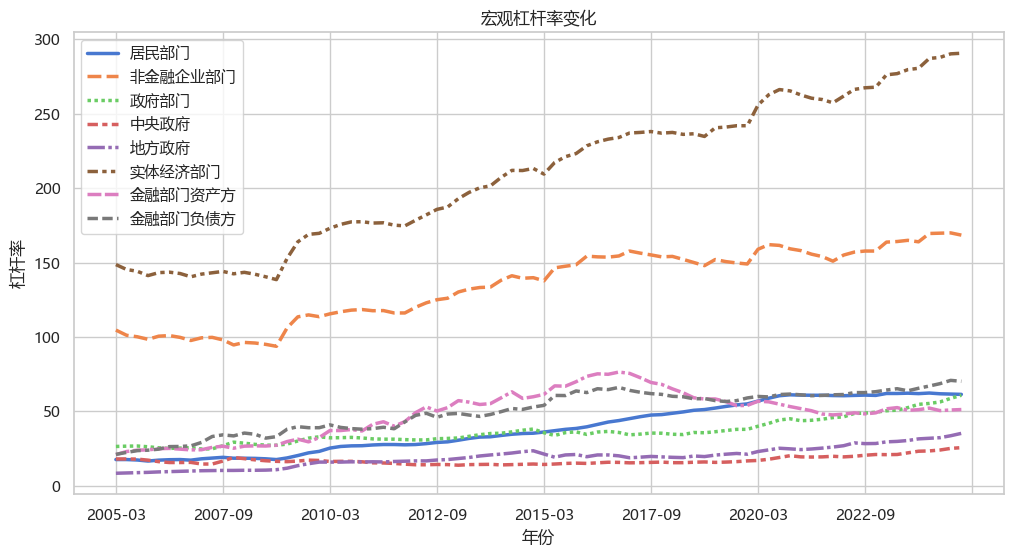

In [7]:
import matplotlib.ticker as ticker
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=macro_cnbs_df) # Seaborn 会自动将列名作为线段标签
# plt.xticks(rotation=75, ha='right')  # 太密了
ax.xaxis.set_major_locator(ticker.MultipleLocator(10)) 
plt.title('宏观杠杆率变化')
plt.ylabel('杠杆率')

📌
- 整体杠杆率呈持续上升趋势，反映出宏观债务水平的持续扩大。
- 自 2020 年第三季度起，居民部门杠杆率趋于稳定，维持在 60% 至 62% 区间。
- 2020 年第三季度后，政府与非金融企业部门杠杆率同步上行，是推动总体杠杆率上升的主要因素。

## 国民经济运行情况

### 企业商品价格指数

In [4]:
macro_china_qyspjg_df = ak.macro_china_qyspjg()

In [5]:
macro_china_qyspjg_df.head()

,月份,总指数-指数值,总指数-同比增长,总指数-环比增长,农产品-指数值,农产品-同比增长,农产品-环比增长,矿产品-指数值,矿产品-同比增长,矿产品-环比增长,煤油电-指数值,煤油电-同比增长,煤油电-环比增长
0,2025年12月份,98.8,0.508647,0.713558,100.4,1.006036,2.974359,112.4,10.738916,1.444043,94.7,-0.941423,-0.210748
1,2025年11月份,98.1,-0.507099,0.822199,97.5,-5.247813,6.209150,110.8,8.203125,1.002735,94.9,0.317125,-0.105263
2,2025年10月份,97.3,-1.717172,-0.409417,91.8,-13.314448,1.101322,109.7,4.675573,-0.091075,95.0,1.387407,-1.144641
3,2025年09月份,97.7,-0.610376,0.411100,90.8,-15.219421,-0.873362,109.8,6.189555,3.487276,96.1,3.444564,2.234043
4,2025年08月份,97.3,-1.816347,0.205973,91.6,-13.175355,-5.274043,106.1,0.473485,3.310613,94.0,-2.892562,1.184069


### 城镇调查失业率

In [10]:
macro_china_urban_unemployment_df = ak.macro_china_urban_unemployment()
macro_china_urban_unemployment_df_wide = macro_china_urban_unemployment_df.pivot(index='date',columns='item',values='value')
macro_china_urban_unemployment_df_wide.index = pd.to_datetime(macro_china_urban_unemployment_df_wide.index, format='%Y%m')

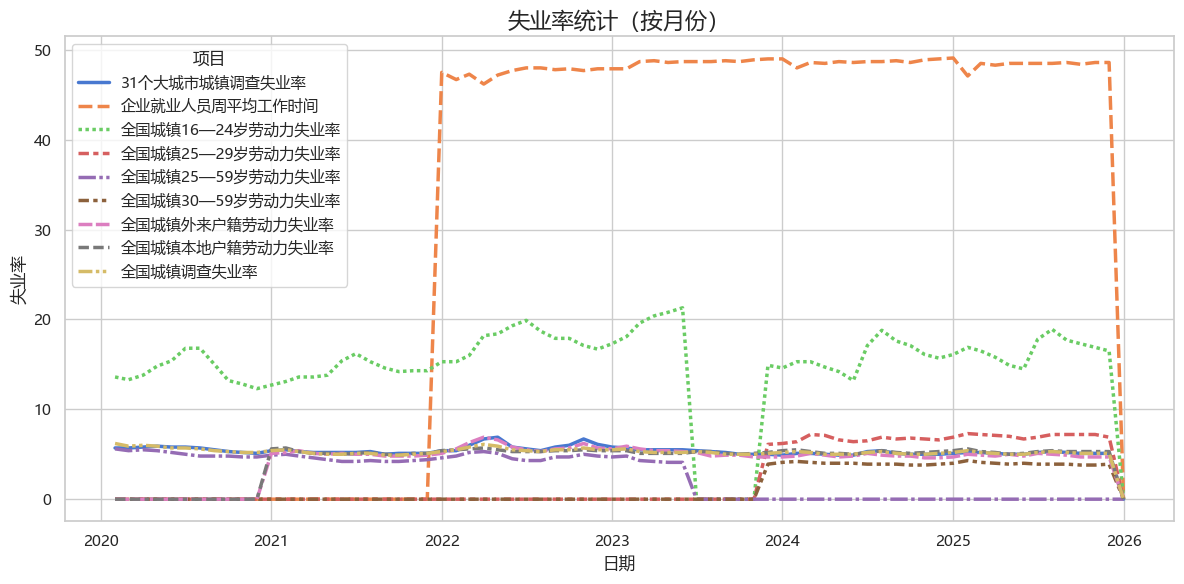

In [13]:
ax = sns.lineplot(data=macro_china_urban_unemployment_df_wide)
plt.title('失业率统计（按月份）', fontsize=16)
plt.xlabel('日期')
plt.ylabel('失业率')
plt.legend(title='项目') #
plt.tight_layout()

📌
- 国家统计局的统计数据不知是否可靠。且部分数据缺失。
- 城镇失业率大概在5%-6%之间。

### LPR品种数据

In [5]:
macro_china_lpr_df = ak.macro_china_lpr()
macro_china_lpr_df.set_index('TRADE_DATE', inplace=True)

  0%|          | 0/4 [00:00<?, ?it/s]

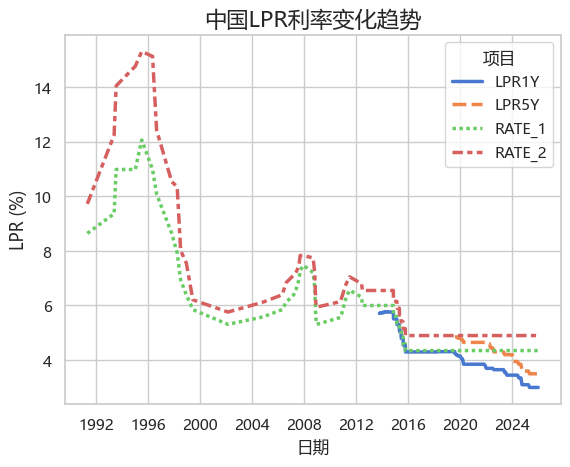

In [6]:
ax = sns.lineplot(data=macro_china_lpr_df)

plt.title("中国LPR利率变化趋势", fontsize=16)
plt.xlabel("日期")
plt.ylabel("LPR (%)")
plt.legend(title="项目")

📌
- LPR 于 2019 年 8 月正式推出，因此早期数据中 LPR 列为空（NaN）属正常情况。
- 当前（最新）**1年期 LPR 为 3.5, 5年期LPR为3.0**，处于历史最低位。
- 自推出以来，**LPR 呈下降趋势**：三年内下调约 **0.8 个百分点**，五年内累计下调约 **1.0 个百分点**。表明贷款难度下降，但消费力长期不足。
- **1年期与5年期 LPR 的利差逐步收窄**，从最初的 0.65 降至当前的 0.4，表明长期贷款成本相对下降，**货币政策更偏向刺激中长期信贷**，也可能反映房地产、基建等长期资金需求较为疲软。


### 社融增量统计

In [7]:
macro_china_shrzgm_df = ak.macro_china_shrzgm()
macro_china_shrzgm_df['月份'] = pd.to_datetime(macro_china_shrzgm_df['月份'], format='%Y%m')
macro_china_shrzgm_df.set_index('月份', inplace=True)
macro_china_shrzgm_df.columns = [ col.replace('其中-','') for col in macro_china_shrzgm_df.columns]

SSLError: HTTPSConnectionPool(host='data.mofcom.gov.cn', port=443): Max retries exceeded with url: /datamofcom/front/gnmy/shrzgmQuery (Caused by SSLError(SSLError(1, '[SSL: SSLV3_ALERT_HANDSHAKE_FAILURE] ssl/tls alert handshake failure (_ssl.c:1010)')))

In [8]:
macro_china_shrzgm_df

,社会融资规模增量,人民币贷款,委托贷款外币贷款,委托贷款,信托贷款,未贴现银行承兑汇票,企业债券,非金融企业境内股票融资
月份,,,,,,,,
2015-01-01,20516,14708,212,832,52,1946,1868,526.0
2015-02-01,13609,11437,-146,1299,38,-592,716,542.0
2015-03-01,12433,9920,-4,1111,-77,-910,1344,639.0
2015-04-01,10582,8045,-265,344,-46,-74,1616,597.0
2015-05-01,12397,8510,81,324,-195,961,1710,584.0
...,...,...,...,...,...,...,...,...
2025-08-01,25660,6253,-91,-165,350,1973,1338,456.0
2025-09-01,35299,16081,-129,283,62,3234,136,499.0
2025-10-01,8178,-154,-200,1654,155,-2895,2500,695.0


In [41]:
plot_df = macro_china_shrzgm_df.loc[macro_china_shrzgm_df.index > '2021-01-01', :][['人民币贷款','企业债券']]

<Axes: title={'center': '社融'}, xlabel='月份'>

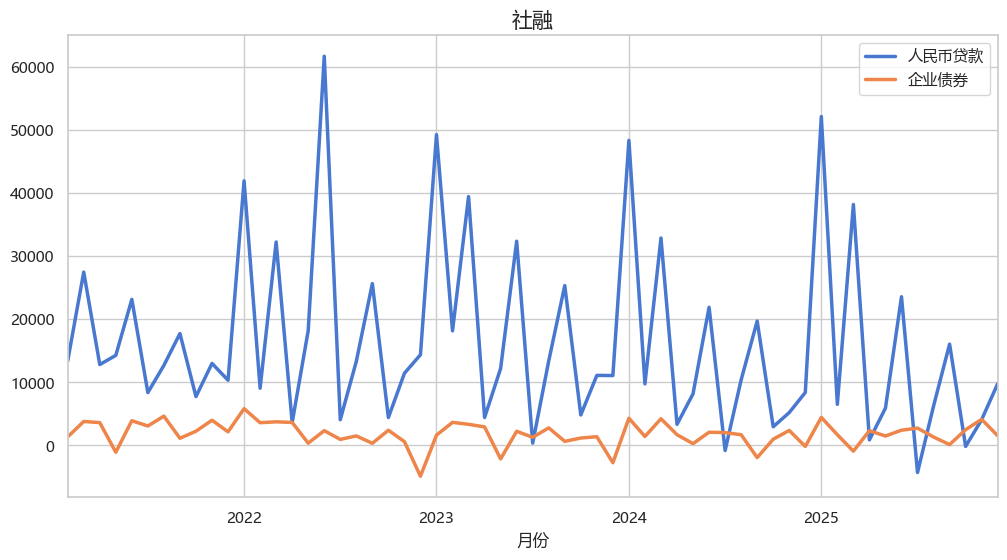

In [42]:
plot_df.plot(title = '社融')

<Axes: title={'center': '社融同比增量'}, xlabel='月份'>

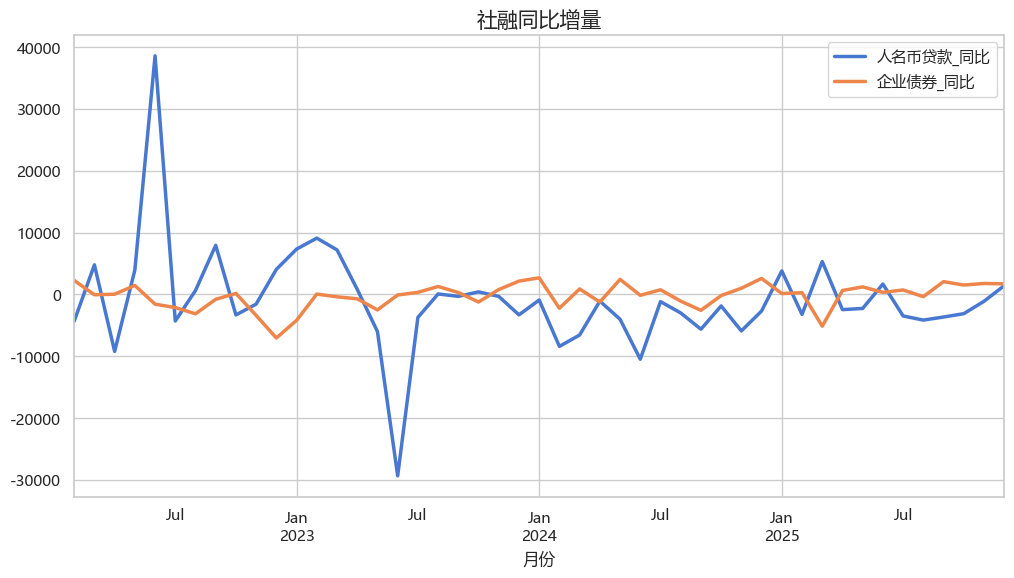

In [48]:
# 消除1月份 人名币贷款 峰值。 采用同比增量。
growth_df = plot_df.diff(12)
growth_df.columns = ['人名币贷款_同比', '企业债券_同比']
growth_df[12:].plot(title = '社融同比增量')

In [46]:
plot_df

,人民币贷款,企业债券
月份,,
2021-02-01,13413,1356
2021-03-01,27511,3807
2021-04-01,12840,3624
2021-05-01,14294,-1077
2021-06-01,23182,3927
2021-07-01,8391,3091
2021-08-01,12713,4649
2021-09-01,17755,1137
2021-10-01,7752,2261


📌 反映每个月中国实体经济从各渠道获得的新增资金总量以及结构
- 社融增量主要来自人名币贷款。
- 每年的趋势大致相同，一月份是社融增量高峰。这体现了政策、银行、企业贷款需求的周期性。

In [38]:
plot_df

,人民币贷款,企业债券
月份,,
2022-02-01,-32.274659,166.224189
2022-03-01,17.374868,-1.497242
2022-04-01,-71.838006,0.772627
2022-05-01,27.536029,-133.983287
2022-06-01,166.409283,-40.259740
2022-07-01,-51.281135,-68.942090
2022-08-01,4.963423,-67.476877
2022-09-01,44.669107,-69.656992
2022-10-01,-42.840557,6.722689


### GDP年率

In [11]:
macro_china_gdp_yearly_df = ak.macro_china_gdp_yearly()

Text(0, 0.5, 'GDP年同比增长率(%)')

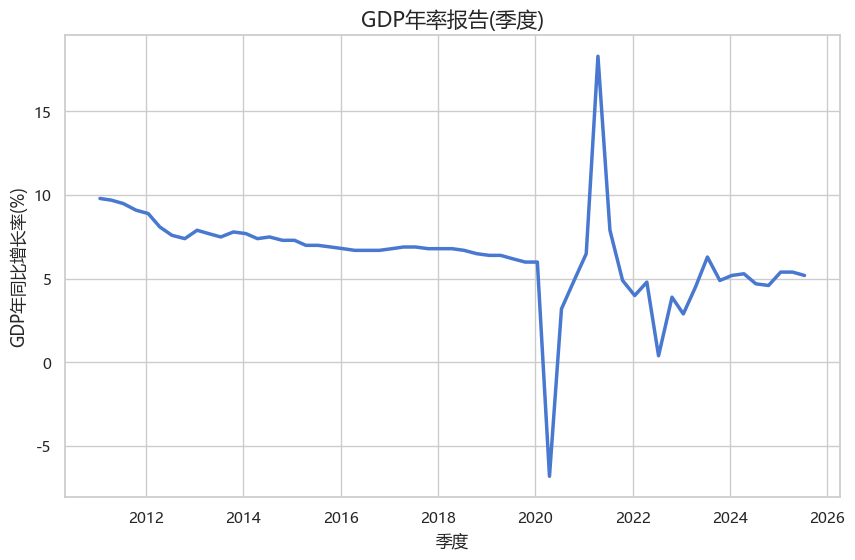

In [13]:
plt.figure(figsize=(10, 6))  
ax = sns.lineplot(data=macro_china_gdp_yearly_df, x='日期', y='今值')

ax.set_title('GDP年率报告(季度)', fontsize=15)
ax.set_xlabel('季度', fontsize=12)
ax.set_ylabel('GDP年同比增长率(%)', fontsize=12)


📌
- 自 2011 年以来，中国 GDP 年增速呈持续放缓趋势，从 9.5% 降至约 5%，反映出经济由高速增长阶段逐步迈向高质量、稳态发展阶段。
- 2020 年一季度，受新冠疫情严重冲击，GDP 增速首次转负，达到 -6.5%。此后虽逐步恢复，到 2023 年三季度，增速才趋于稳定。
- 然而，增速“稳定”并不意味着 GDP 总量已完全恢复至疫情前的自然增长轨迹。🔍增速仅反映相对变化率，要评估真实经济恢复情况，应结合GDP总量综合判断。


### CPI

In [17]:
macro_china_cpi_monthly_df = ak.macro_china_cpi_monthly()

Text(0, 0.5, 'CPI月环比增长率(%)')

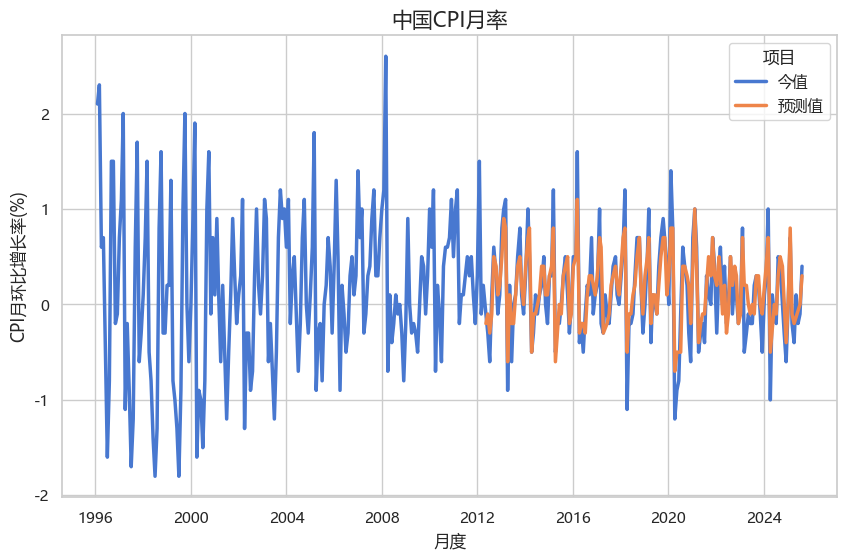

In [19]:
df_melted = macro_china_cpi_monthly_df.melt(
    id_vars=['日期'], 
    value_vars=['今值', '预测值'], 
    var_name='项目', 
    value_name='CPI月环比增长率(%)'
)
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=df_melted, x='日期', y='CPI月环比增长率(%)', hue='项目')

ax.set_title('中国CPI月率', fontsize=15)
ax.set_xlabel('月度', fontsize=12)
ax.set_ylabel('CPI月环比增长率(%)', fontsize=12)

📌
- 长期来看，CPI波动幅度逐渐减小，消费物价趋于稳定，因此CPI更适合反映短期几个月内的价格变动。
- 2025年3、4、6月CPI同比连续为负，尽管5月小幅回升至0.1%，但反弹力度有限，显示整体消费需求偏弱。
- 若CPI持续负增长，将可能引发通缩风险，其传导机制包括：
    1. 供大于求 → 商品价格下行 → 企业销售困难、盈利下降 → 减少投资、裁员减产；
    2. 企业经营压力传导至居民 → 收入下降 → 消费进一步收缩，形成恶性循环；
    3. 通缩期间货币购买力上升 → 债务实际负担加重 → 企业、个人违约风险上升，可能引发信用危机与破产潮。
- 当前LPR（贷款市场报价利率）呈下降趋势，反映出政府正在通过信贷宽松和低利率政策提振消费和投资，缓解通缩压力。


### PPI

In [29]:
macro_china_ppi_yearly_df = ak.macro_china_ppi_yearly()

Text(0, 0.5, 'PPI月环比增长率(%)')

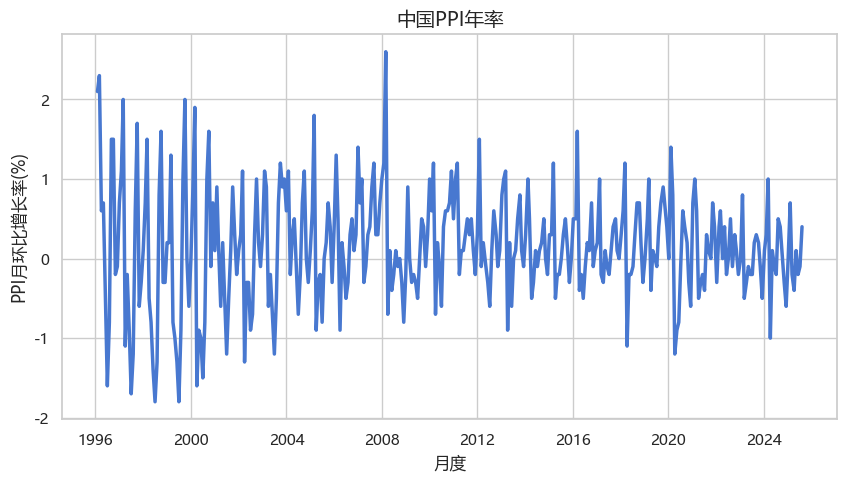

In [20]:
plt.figure(figsize=(10, 5))

ax = sns.lineplot(data=macro_china_cpi_monthly_df, x='日期', y='今值')

ax.set_title('中国PPI年率', fontsize=14)
ax.set_xlabel('月度', fontsize=12)
ax.set_ylabel('PPI月环比增长率(%)', fontsize=12)

📌
- 长期来看，PPI波动幅度逐渐减小，生产端趋于稳定，因此CPI更适合反映短期几个月内的价格变动。
- 2025以来，和CPI同步。

## 金融指标

### 外汇储备

In [21]:
macro_china_fx_reserves_yearly_df = ak.macro_china_fx_reserves_yearly()
macro_china_fx_reserves_yearly_df['日期'] = pd.to_datetime(macro_china_fx_reserves_yearly_df['日期'])
macro_china_fx_reserves_yearly_df['year'] =  macro_china_fx_reserves_yearly_df['日期'].dt.year
macro_china_fx_reserves_yearly_df['month'] =  macro_china_fx_reserves_yearly_df['日期'].dt.month

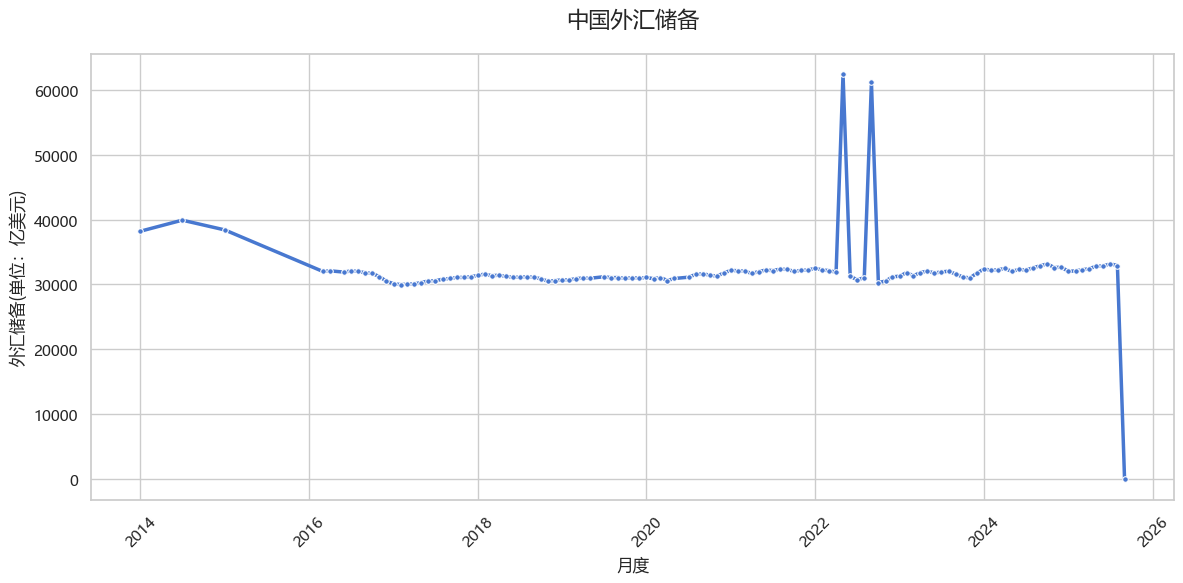

In [23]:
plotdf = macro_china_fx_reserves_yearly_df.groupby(['year','month'])['今值'].sum()
plotdf = plotdf.reset_index()
plotdf['日期'] = pd.to_datetime({
    'year':plotdf['year'],
    'month':plotdf['month'],
    'day':1, # 第一天默认
    })
plt.figure(figsize=(12, 6))

ax = sns.lineplot(data=plotdf, x='日期', y='今值', marker='o', markersize=4)

ax.set_title('中国外汇储备', fontsize=16, pad=20)
ax.set_xlabel('月度', fontsize=12)
ax.set_ylabel('外汇储备(单位：亿美元)', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

📌
- 最新外汇储备 **32850** 亿美元

### M2货币供应量

In [24]:
macro_china_m2_yearly_df = ak.macro_china_m2_yearly()
macro_china_m2_yearly_df['日期'] = pd.to_datetime(macro_china_m2_yearly_df['日期'])
macro_china_m2_yearly_df['year'] =  macro_china_m2_yearly_df['日期'].dt.year
macro_china_m2_yearly_df['month'] =  macro_china_m2_yearly_df['日期'].dt.month
plotdf = macro_china_m2_yearly_df.groupby(['year','month'])['今值'].sum()

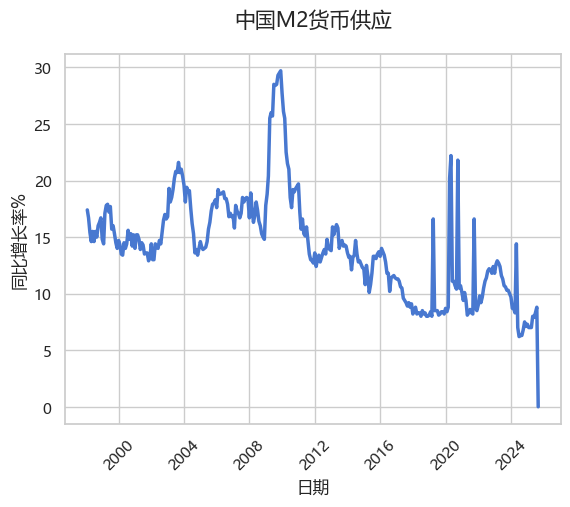

In [25]:
plotdf = plotdf.reset_index()
plotdf['日期'] = pd.to_datetime({
    'year':plotdf['year'],
    'month':plotdf['month'],
    'day':1, # 第一天默认
    })

ax = sns.lineplot(data=plotdf, x='日期', y='今值')

ax.set_title('中国M2货币供应', fontsize=15, pad=20)
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('同比增长率%', fontsize=12)

plt.xticks(rotation=45)

plt.show()

📌 
- 5月的M2货币同比增长7.9%  
- ✅ 带加入后面的货币供应量数据一起

###  新房价价格指数

In [26]:
city1 = '上海'
city2 = '成都'
macro_china_new_house_price_df = ak.macro_china_new_house_price(city_first=city1, 
                                                                city_second=city2)

In [27]:
# 把指标扁平化作为 合并一列，
plotdf = pd.melt(
    macro_china_new_house_price_df,
    id_vars=['日期', '城市'],
    value_vars=[
        '新建商品住宅价格指数-同比', 
        '新建商品住宅价格指数-环比', 
        '新建商品住宅价格指数-定基',
        '二手住宅价格指数-同比', 
        '二手住宅价格指数-环比', 
        '二手住宅价格指数-定基'
    ],
    var_name='项目',
    value_name='增长率%'
)


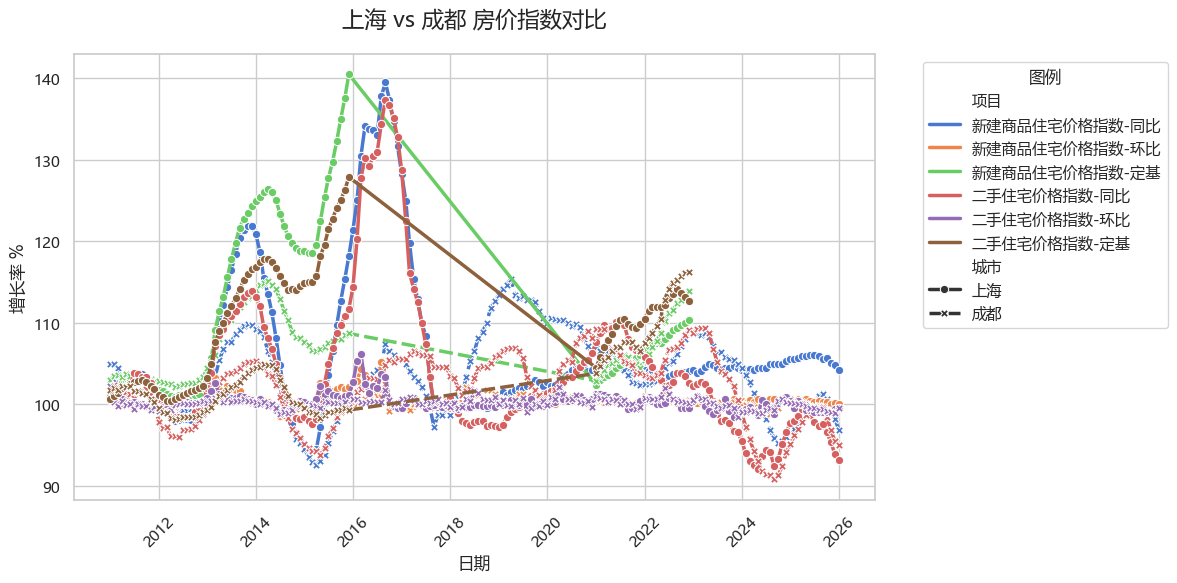

In [28]:
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=plotdf, 
    x='日期', 
    y='增长率%', 
    hue='项目',    # 区分价格指数类型
    style='城市',  # 区分城市（实线/虚线）
    markers=True,  # 加上数据点标记，方便辨认
    dashes=True    # 启用虚线效果
)

ax.set_title(f'{city1} vs {city2} 房价指数对比', fontsize=16, pad=20)
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('增长率 %', fontsize=12)

plt.legend(title='图例', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()

### 企业景气及企业家信心指数

In [29]:
macro_china_enterprise_boom_index_df = ak.macro_china_enterprise_boom_index()

In [30]:
def jidu_to_datetime(s):
    if not isinstance(s, str):
        return pd.NaT  # 表示时间缺失值
    year = s[:4]
    quarter = s[6]
    month = str((int(quarter) - 1) * 3 + 1 )
    return pd.to_datetime(f'{year}-{month}-01')

In [31]:
macro_china_enterprise_boom_index_df['quarter'] = macro_china_enterprise_boom_index_df['季度'].apply(jidu_to_datetime)

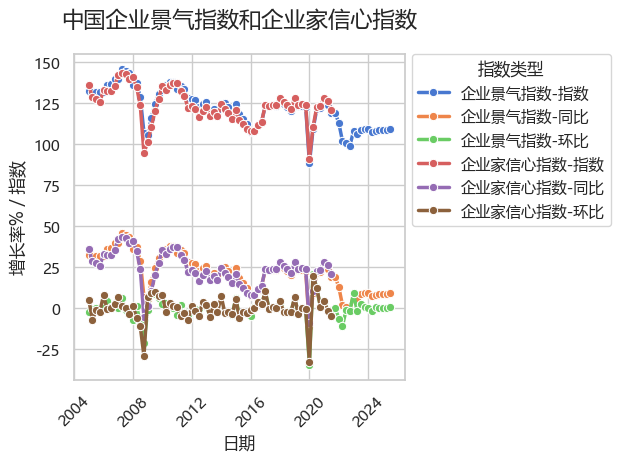

In [33]:
value_vars = [
    '企业景气指数-指数', '企业景气指数-同比', '企业景气指数-环比', 
    '企业家信心指数-指数', '企业家信心指数-同比', '企业家信心指数-环比'
]

plot_df_melted = macro_china_enterprise_boom_index_df.melt(
    id_vars=['quarter'], 
    value_vars=value_vars,
    var_name='指数类型', 
    value_name='数值'
)
ax = sns.lineplot(
    data=plot_df_melted, 
    x='quarter', 
    y='数值', 
    hue='指数类型', 
    marker='o'  # 增加点标记，方便区分 6 条线
)

ax.set_title('中国企业景气指数和企业家信心指数', fontsize=16, pad=20)
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('增长率% / 指数', fontsize=12)

plt.legend(title='指数类型', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.xticks(rotation=45)
plt.tight_layout()


### 税收收入

In [34]:
macro_china_national_tax_receipts_df = ak.macro_china_national_tax_receipts()

In [35]:
# copy保证新的副本
plot_year_df = macro_china_national_tax_receipts_df[macro_china_national_tax_receipts_df['季度'].str.contains('1-4季度')].copy()


In [36]:
plot_year_df['年份'] = plot_year_df['季度'].apply(lambda x:pd.to_datetime(f'{x[:4]}', format='%Y'))

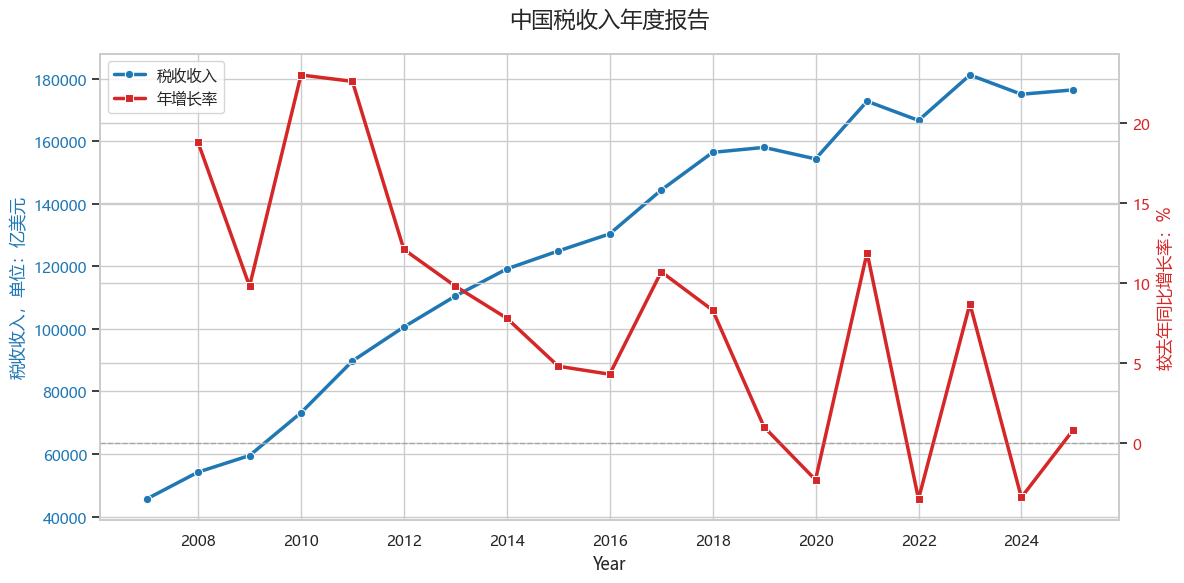

In [37]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=plot_year_df, 
    x='年份', 
    y='税收收入合计', 
    ax=ax1, 
    label='税收收入', 
    color='tab:blue', 
    marker='o'
)
ax1.set_title('中国税收入年度报告', fontsize=16, pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('税收收入，单位：亿美元', fontsize=12, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue') # 让 Y 轴刻度颜色与线条一致

# 4. 创建次轴 (ax2)，共用 X 轴
ax2 = ax1.twinx()

# --- 绘制右轴数据 (年增长率) ---
sns.lineplot(
    data=plot_year_df, 
    x='年份', 
    y='较上年同期', 
    ax=ax2, 
    label='年增长率', 
    color='tab:red', 
    marker='s' # 使用不同的标记形状
)
ax2.set_ylabel('较去年同比增长率：%', fontsize=12, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 5. 合并图例
# 因为 ax1 和 ax2 是独立的，直接 show 会出现两个图例框
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax2.get_legend().remove() # 移除多余的图例

# 6. 辅助线（可选：在增长率 0 位画一条基准线）
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()

### 银行理财产品发行数量

In [38]:
macro_china_bank_financing_df = ak.macro_china_bank_financing()

In [39]:
macro_china_bank_financing_df['日期'] = pd.to_datetime(macro_china_bank_financing_df['日期'])


In [40]:
# 配合%显示tickformat
macro_china_bank_financing_df['涨跌幅'] = macro_china_bank_financing_df['涨跌幅'].apply(lambda x:x/100)
macro_china_bank_financing_df['近3月涨跌幅'] = macro_china_bank_financing_df['近3月涨跌幅'].apply(lambda x:x/100)
macro_china_bank_financing_df['近6月涨跌幅'] = macro_china_bank_financing_df['近6月涨跌幅'].apply(lambda x:x/100)
macro_china_bank_financing_df['近1年涨跌幅'] = macro_china_bank_financing_df['近1年涨跌幅'].apply(lambda x:x/100)
macro_china_bank_financing_df['近2年涨跌幅'] = macro_china_bank_financing_df['近2年涨跌幅'].apply(lambda x:x/100)
macro_china_bank_financing_df['近3年涨跌幅'] = macro_china_bank_financing_df['近3年涨跌幅'].apply(lambda x:x/100)


In [41]:
# 2015 年之后比较稳定
macro_china_bank_financing_df = macro_china_bank_financing_df[macro_china_bank_financing_df['日期'].dt.year > 2015]

In [42]:
plotdf = macro_china_bank_financing_df

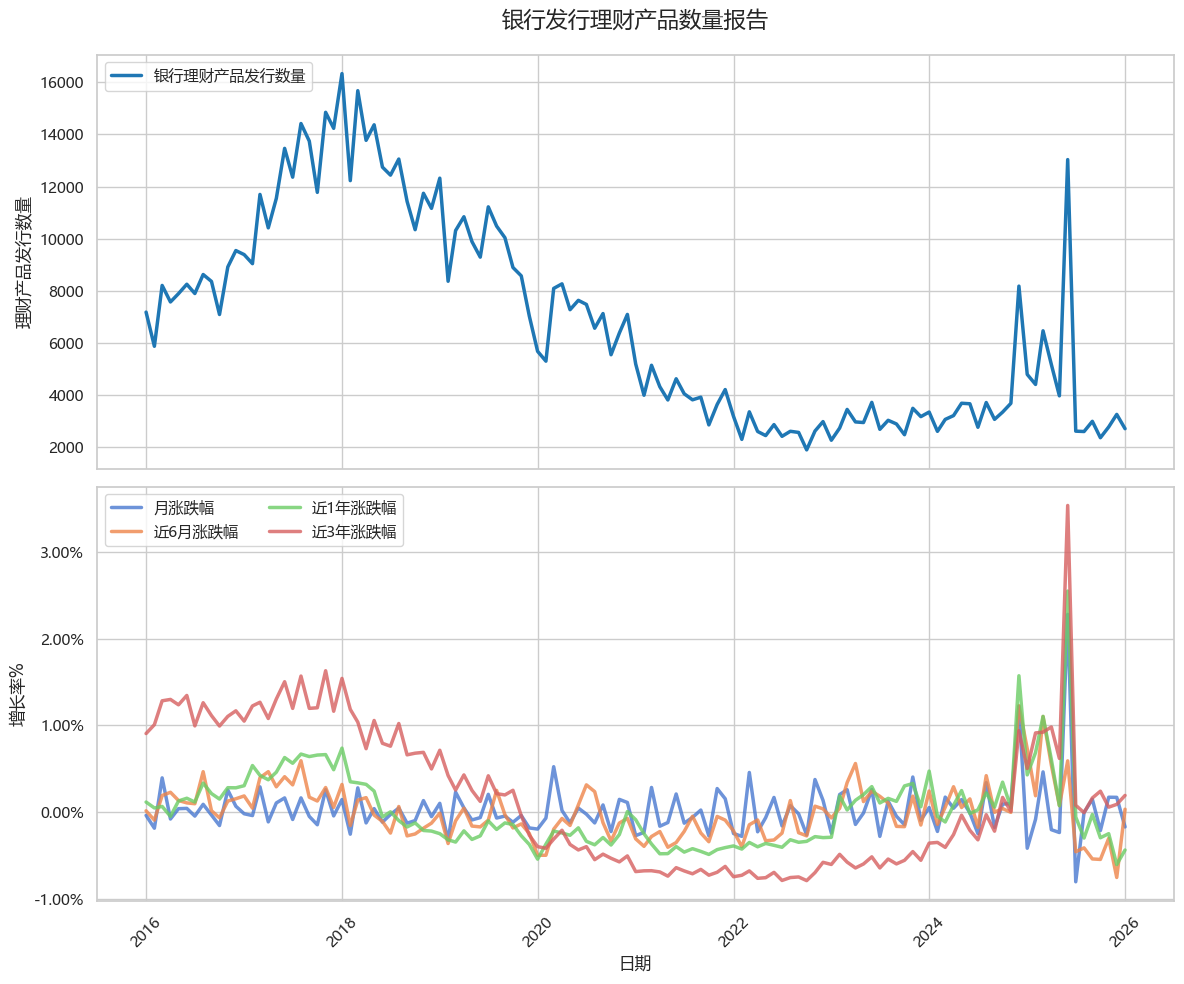

In [43]:
# 3. 创建子图布局：2行1列，共享X轴，设置高度比例
# gridspec_kw 可以调整子图的高度比例，比如让上图大一点
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [1, 1]})

# --- 上子图 (Row 1): 发行数量 ---
sns.lineplot(data=plotdf, x='日期', y='最新值', ax=ax1, label='银行理财产品发行数量', color='tab:blue')
ax1.set_title('银行发行理财产品数量报告', fontsize=16, pad=20)
ax1.set_ylabel('理财产品发行数量', fontsize=12)
ax1.legend(loc='upper left')

# --- 下子图 (Row 2): 多维度涨跌幅 ---
# 依次绘制多条线，手动指定 ax=ax2
sns.lineplot(data=plotdf, x='日期', y='涨跌幅', ax=ax2, label='月涨跌幅', alpha=0.8)
sns.lineplot(data=plotdf, x='日期', y='近6月涨跌幅', ax=ax2, label='近6月涨跌幅', alpha=0.8)
sns.lineplot(data=plotdf, x='日期', y='近1年涨跌幅', ax=ax2, label='近1年涨跌幅', alpha=0.8)
sns.lineplot(data=plotdf, x='日期', y='近3年涨跌幅', ax=ax2, label='近3年涨跌幅', alpha=0.8)

# 设置下子图属性
ax2.set_ylabel('增长率%', fontsize=12)
# 格式化 Y 轴为百分比（如果数据已经是 0.05 这种格式，使用 PercentFormatter）
from matplotlib.ticker import PercentFormatter
# 如果数据是 5(表示5%), 用下行；如果是 0.05(表示5%), 用 PercentFormatter(1.0)
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1 if plotdf['涨跌幅'].max() <= 1 else 100))

# 4. 全局优化
plt.xlabel('日期', fontsize=12)
plt.xticks(rotation=45)

# 调整子图间距 (对应 vertical_spacing)
plt.subplots_adjust(hspace=0.08) 

# 合并或美化图例
ax2.legend(loc='upper left', ncol=2) # 4条线，两列显示更整齐

plt.tight_layout()